# Rebuttal experiment: loss-weight ($\lambda$) sensitivity sweep

**Addresses nG29's round-2 comment directly**: *"loss ablations are included and thorough... On this
matter, hyperparameter sweeps or details on hyperparameter tuning (which were also mentioned as part
of this concern) are still missing."*

`component_ablation.ipynb` answers the **binary** question (remove each loss term entirely).
`k_sensitivity_sweep.ipynb` answers the **K** question. Neither answers "how sensitive is
performance to the *magnitude* of each loss weight" -- that's this notebook.

This is a **coordinate sweep**: each of the four scalar hyperparameters the paper reports a fixed
value for (`appendix/training.tex`, Total Objective) is varied one at a time around its paper
value, holding the other three -- and everything else in `LAMBDA_PROTO_UMAP_PRECON` -- fixed at the
paper's own config.

| Paper symbol | Config key (verified against `trainers/scproto.py` / `experiments/tasks.py`) | Paper value | Sweep grid |
|---|---|---|---|
| $\lambda$ ($\mathcal{L}_{\text{rec}}$ weight) | `lambda_proto_recon` | 0.01 | 0, 0.003, 0.01, 0.03, 0.1 |
| $\lambda_n$ ($\mathcal{L}_{\text{nassoc}}$ weight) | `lambda_nassoc` | 1.0 | 0, 0.3, 1.0, 3.0, 10.0 |
| $\lambda_u$ ($\mathcal{L}_{\text{usage}}$ weight) | `lambda_proto_usage` | 0.1 | 0, 0.03, 0.1, 0.3, 1.0 |
| $\alpha$ (nassoc diag/off-diag balance) | `nassoc_alpha` | 1.0 | 0, 0.25, 0.5, 1.0, 2.0 |

Note: `lambda_recon` (no `proto_`) is a separate, disabled (`=0`) legacy code path -- not part of
the paper's objective at all. Don't confuse it with `lambda_proto_recon` above. `lambda_umap`
(the community-loss weight) is *not* swept -- the paper reports it as a fixed implicit weight of 1
with no companion "what if this were 0.5x" claim to interrogate, unlike the other four.

Each grid's zero point subsumes `component_ablation.ipynb`'s corresponding `no_*` arm (same
config, same expected result) -- listed here anyway for a complete, self-contained curve per
parameter. The non-zero paper-default grid point (`full`) is a fresh run under this notebook's own
`lsweep_full` tag rather than a reused checkpoint from `component_ablation.ipynb`, so this notebook
stays independently re-runnable; its numbers should match `component_ablation.ipynb`'s `full` arm
as a cross-notebook sanity check.

Pancreas only for now, matching the precedent nG29 already accepted for the round-1 ablation table
(pancreas first, lung/PBMC to follow).

## Setup

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Identical install sequence to component_ablation.ipynb / batch_correct_then_cluster_baselines.ipynb
# / k_sensitivity_sweep.ipynb (the verified-working setup in this folder). SEACells is a training-time
# dependency here too (paper's waypoint init, prot_init='waypoint', uses SEACells' diffusion-map
# MaxMin routine), not just a baseline -- needed even though this notebook trains no SEACells baselines.
!pip install -q scarches faiss-gpu-cu12 scib-metrics
!pip install git+https://github.com/dpeerlab/SEACells.git --quiet --no-deps
!pip install numpy scipy --upgrade -q
!pip install -q palantir harmonypy
!pip install -q "numpy==1.26.4" "scipy==1.13.1"
!pip install --upgrade --force-reinstall numpy cupy-cuda12x
!pip install "numpy<2.3"

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 9.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 130.2/130.2 kB 16.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.4/48.4 MB 29.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.0/42.0 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 187.5/187.5 kB 19.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.7/5.7 MB 74.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.9/3.9 MB 79.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 90.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.0/11.0 MB 32.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 29.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 711.2/711.2 kB 29.0 MB/s eta 0:00:00
   ━━━━━━━

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.5/16.5 MB 135.0 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 2.5.1
    Uninstalling numpy-2.5.1:
      Successfully uninstalled numpy-2.5.1
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
seacells 0.3.3 requires pyranges, which is not installed.
anndata 0.13.2 requires scipy!=1.17.0,>=1.14, but you have scipy 1.13.1 which is incompatible.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 3.0.5 which is incompatible.
cuml-cu12 26.2.0 requires numba<0.62.0,>=0.60.0, but you have numba 0.66.0 which is incompatible.
pytensor 2.38.3 requires numba<=0.65.1,>=0.58, but you have numba 0.66.0 which is incompatible.
cudf-cu12 26.2.1 requires numba<0.62.0,>=0.60.0, but you have numba 0.66.0 whi

In [ ]:
# Auto-restart the runtime so the numpy/scipy/anndata upgrades above actually take effect --
# drive.mount above already imports numpy/scipy transitively, and C-extension modules don't pick up
# an in-process upgrade. Under Runtime > Run all, Colab detects this kernel death, silently respawns
# a fresh kernel, and continues running the remaining cells automatically -- no manual restart needed.
print("Restarting runtime to apply package upgrades...")
import os
os.kill(os.getpid(), 9)

In [1]:
%run /content/drive/MyDrive/codes/interpretable-prototype/notebooks/nb_setup.py

nb_setup done. Available: get_trainer, run_mc_task, fig_*, LAMBDA_PROTO_UMAP, LAMBDA_PROTO_UMAP_PRECON, LAMBDA_PARAM_UMAP, LAMBDA_RECON_ONLY, train_sure, eval_sure_task1/2/3
Configs: {'LAMBDA_PROTO_UMAP': {'lambda_umap': 1, 'lambda_swav': 0, 'lambda_kl': 0, 'lambda_recon': 0, 'lambda_proto_recon': 0.0, 'umap_similarity': 'proto'}, 'LAMBDA_PARAM_UMAP': {'lambda_umap': 1, 'lambda_swav': 0, 'lambda_kl': 0, 'lambda_recon': 0, 'lambda_proto_recon': 0.0, 'umap_similarity': 'embedding'}, 'LAMBDA_RECON_ONLY': {'lambda_umap': 0, 'lambda_swav': 0, 'lambda_kl': 0, 'lambda_recon': 1, 'lambda_proto_recon': 0.0}}


In [2]:
# Extra imports not already covered by nb_setup.py (which already pulls in get_trainer, run_mc_task,
# LAMBDA_PROTO_UMAP_PRECON, and rare_celltype_purity_table / show_table via
# `from interpretable_ssl.evaluation.paper_figures import *` / `...result_tables import *`).
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

print("extra imports ready")

extra imports ready


## Config

`PARAM_META` is the single source of truth for the four swept hyperparameters: config key, paper's
own value, and the grid to sweep. `BASE` is the paper's full config (`LAMBDA_PROTO_UMAP_PRECON`);
each arm overrides exactly one key.

In [3]:
RUN_DATASETS = ['pancreas']  # lung / pbmc-immune wired identically below, run once pancreas looks right

RUN_TAG = 'lsweep'  # distinctive experiment_prefix -- avoids the folder-substring ambiguity bug
                     # documented in logs/canonical_scproto_run.md (same reasoning as k_sensitivity_sweep.ipynb's RUN_TAG)

COMMON_KWARGS = dict(   # identical training budget to component_ablation.ipynb / k_sensitivity_sweep.ipynb
    cvae_epochs=50,
    train_epochs=50,
    eval_freq=3,
    patience=6,
    batch_size=1024,
    umap_steps_per_epoch=500,
)

BASE = dict(LAMBDA_PROTO_UMAP_PRECON)  # the paper's full-model config -- verified values:
                                        # lambda_proto_recon=0.01, lambda_nassoc=1, lambda_proto_usage=0.1
                                        # (nassoc_alpha=1.0 comes from configs/defaults.py, not overridden here)

PARAM_META = {
    'lambda_proto_recon': dict(symbol='λ (recon)',                default=0.01, grid=[0.0, 0.003, 0.01, 0.03, 0.1]),
    'lambda_nassoc':      dict(symbol='λn (nassoc)',               default=1.0,  grid=[0.0, 0.3,   1.0,  3.0,  10.0]),
    'lambda_proto_usage': dict(symbol='λu (usage)',                default=0.1,  grid=[0.0, 0.03,  0.1,  0.3,  1.0]),
    'nassoc_alpha':       dict(symbol='α (nassoc diag/off-diag)',  default=1.0,  grid=[0.0, 0.25,  0.5,  1.0,  2.0]),
}

TASK1_PAIRS = [   # same convention as k_sensitivity_sweep.ipynb
    ('weighted_mean_cell_type_purity', 'weighted_std_cell_type_purity', 'CT Purity'),
    ('weighted_mean_batch_entropy',    'weighted_std_batch_entropy',    'Batch Entropy'),
    ('mean_modularity_batch',          'std_modularity_batch',          'Modularity'),
    ('coverage',                       None,                            'Coverage'),
    ('unused_proto_ratio',             None,                            'Unused Proto Ratio'),
]
RARE_PAIRS = [
    ('batch_rare_coverage_mean',    'batch_rare_coverage_std',    'Rare Coverage'),
    ('batch_rare_homogeneity_mean', 'batch_rare_homogeneity_std', 'Rare Homogeneity'),
    ('batch_rare_f1_macro_mean',    'batch_rare_f1_macro_std',    'Rare F1 (macro)'),
]


def _fmt_val(v):
    """0.003 -> '0p003' -- keeps folder/tag names filesystem- and eval-safe."""
    return f'{v:g}'.replace('.', 'p').replace('-', 'm')


def build_variants():
    """One shared 'full' anchor (paper's own config) + non-default grid points for each param.
    Skips re-adding a param's default value since 'full' already covers it -- avoids training the
    same config twice under different tags."""
    variants = {'full': {}}
    display_names = {'full': 'Full model (paper defaults)'}
    point_meta = {'full': {'param': None, 'value': None}}  # which param/value each tag belongs to, for plotting

    for param, meta in PARAM_META.items():
        for v in meta['grid']:
            if v == meta['default']:
                continue  # 'full' already covers this point
            tag = f"{param}_{_fmt_val(v)}"
            variants[tag] = {param: v}
            display_names[tag] = f"{meta['symbol']}={v:g}"
            point_meta[tag] = {'param': param, 'value': v}

    return variants, display_names, point_meta


VARIANTS, VARIANT_DISPLAY_NAMES, POINT_META = build_variants()
print(f"{len(VARIANTS)} arms total (1 shared anchor + "
      f"{sum(len(m['grid']) - 1 for m in PARAM_META.values())} non-default grid points)")
for tag in VARIANTS:
    print(' ', tag, '->', VARIANTS[tag] or '(paper defaults)')

17 arms total (1 shared anchor + 16 non-default grid points)
  full -> (paper defaults)
  lambda_proto_recon_0 -> {'lambda_proto_recon': 0.0}
  lambda_proto_recon_0p003 -> {'lambda_proto_recon': 0.003}
  lambda_proto_recon_0p03 -> {'lambda_proto_recon': 0.03}
  lambda_proto_recon_0p1 -> {'lambda_proto_recon': 0.1}
  lambda_nassoc_0 -> {'lambda_nassoc': 0.0}
  lambda_nassoc_0p3 -> {'lambda_nassoc': 0.3}
  lambda_nassoc_3 -> {'lambda_nassoc': 3.0}
  lambda_nassoc_10 -> {'lambda_nassoc': 10.0}
  lambda_proto_usage_0 -> {'lambda_proto_usage': 0.0}
  lambda_proto_usage_0p03 -> {'lambda_proto_usage': 0.03}
  lambda_proto_usage_0p3 -> {'lambda_proto_usage': 0.3}
  lambda_proto_usage_1 -> {'lambda_proto_usage': 1.0}
  nassoc_alpha_0 -> {'nassoc_alpha': 0.0}
  nassoc_alpha_0p25 -> {'nassoc_alpha': 0.25}
  nassoc_alpha_0p5 -> {'nassoc_alpha': 0.5}
  nassoc_alpha_2 -> {'nassoc_alpha': 2.0}


## Helper functions

In [4]:
from interpretable_ssl.evaluation.trainer_diagnostics import (
    prototype_redundancy,
    active_prototype_count,
    macro_celltype_purity,
    format_mean_std,
)
from interpretable_ssl.experiments.tasks import (
    run_ablation_variant,
    run_all_variants_for_dataset,
    _checkpoint_exists,
)
from interpretable_ssl.datasets.dataset_configs import DATASETS
import json
import glob

print("helper functions imported from interpretable_ssl.evaluation.trainer_diagnostics "
      "and interpretable_ssl.experiments.tasks")

helper functions imported from interpretable_ssl.evaluation.trainer_diagnostics and interpretable_ssl.experiments.tasks


In [5]:
def _resolve_dump_dir(ds_id, experiment_name):
    matches = glob.glob(os.path.join(os.environ['MODEL_DIR'], ds_id, f'{experiment_name}_*'))
    return matches[0] if matches else None


def run_all_variants_metrics_only(ds_id, ablations, variant_display_names=None, experiment_prefix=RUN_TAG):
    """Reads each arm's already-saved metrics.json straight off disk -- NO
    model reload, NO checkpoint load, NO dataset load, NO GPU, NO training.
    This is what was OOM-ing before: run_all_variants_reload_only still
    reconstructed a full trainer (dataset + EdgeDataset + model) per arm just
    to re-derive numbers the trainer itself already logged to metrics.json
    during its original eval. Reading that file directly skips all of it.

    Arms with no saved metrics.json (never trained, or trained but eval never
    completed) are skipped and reported by name -- nothing gets recomputed,
    retrained, or guessed at for them.

    proto_cosine_sim_mean/max (prototype_redundancy) are NOT included here --
    those need the actual prototype vectors, which only live inside the model
    checkpoint, not in anything saved to disk as plain metrics. n_active_prototypes
    / K / active_frac ARE included -- derived from the saved cluster assignments
    alone (clusters.npz), no model needed for those.
    """
    results = {}
    skipped = []
    for tag in ablations:
        experiment_name = f'{experiment_prefix}_{tag}'
        dump_dir = _resolve_dump_dir(ds_id, experiment_name)
        metrics_path = os.path.join(dump_dir, 'metrics.json') if dump_dir else None
        if not dump_dir or not os.path.exists(metrics_path):
            skipped.append(tag)
            continue

        with open(metrics_path) as f:
            res = json.load(f)

        clusters_path = os.path.join(dump_dir, 'clusters.npz')
        if os.path.exists(clusters_path):
            data = np.load(clusters_path, allow_pickle=True)
            assignments = data['assignments']
            K = DATASETS[ds_id]['num_prototypes']
            n_active = int(len(np.unique(assignments)))
            res['n_active_prototypes'] = n_active
            res['K'] = int(K)
            res['active_frac'] = n_active / K

        results[tag] = res

    if skipped:
        print(f"[{ds_id}] {len(skipped)}/{len(ablations)} arm(s) skipped -- no saved "
              f"metrics.json found, NOT recomputed: {skipped}")
    else:
        print(f"[{ds_id}] all {len(ablations)} arms loaded from cached metrics.json -- "
              f"no model, dataset, or GPU touched")
    return results

## Run: Pancreas

In [6]:
results = {}

# Metrics-only: reads cached metrics.json per arm, touches no model/dataset/GPU.
results['pancreas'] = run_all_variants_metrics_only(
    'pancreas', VARIANTS, variant_display_names=VARIANT_DISPLAY_NAMES, experiment_prefix=RUN_TAG,
)

[pancreas] all 17 arms loaded from cached metrics.json -- no model, dataset, or GPU touched


## Run: Lung + PBMC (Immune) -- uncomment once Pancreas looks right

In [7]:
for _ds in ['lung', 'pbmc-immune']:
    results[_ds] = run_all_variants_metrics_only(
        _ds, VARIANTS, variant_display_names=VARIANT_DISPLAY_NAMES, experiment_prefix=RUN_TAG,
    )

[lung] all 17 arms loaded from cached metrics.json -- no model, dataset, or GPU touched
[pbmc-immune] all 17 arms loaded from cached metrics.json -- no model, dataset, or GPU touched


## Results

In [8]:
rows = []
for ds_id, ds_results in results.items():
    for tag, res in ds_results.items():
        row = {'dataset': ds_id, 'tag': tag, 'variant': VARIANT_DISPLAY_NAMES[tag]}
        row.update(res)
        rows.append(row)

df_ablation = pd.DataFrame(rows).set_index(['dataset', 'variant'])

# --- Task 1 / Task 2 headline metrics (same numbers the paper's own tables use) ---
main_cols = ['purity', 'niche_purity', 'batch_entropy', 'modularity',
             'coverage', 'dge_rbo_avg', 'dge_kendall_avg', 'dge_jaccard_avg',
             'scgraph_corr_avg', 'scgraph_corr_std']
df_ablation[[c for c in main_cols if c in df_ablation.columns]]

modularity  coverage  dge_rbo_avg  \
dataset     variant                                                            
pancreas    Full model (paper defaults)      0.687854  0.928571     0.175694   
            λ (recon)=0                      0.703312  0.928571     0.142641   
            λ (recon)=0.003                  0.674747  0.928571     0.184292   
            λ (recon)=0.03                   0.688478  1.000000     0.187571   
            λ (recon)=0.1                    0.701596  0.928571     0.151576   
            λn (nassoc)=0                    0.707729  0.928571     0.137999   
            λn (nassoc)=0.3                  0.697574  0.928571     0.123801   
            λn (nassoc)=3                    0.630032  0.928571     0.170788   
            λn (nassoc)=10                   0.583623  0.928571     0.223743   
            λu (usage)=0                     0.720108  0.785714     0.092055   
            λu (usage)=0.03                  0.704087  0.928571     0.134032   
            λu (usage)=0.3                   0.668994  0.928571     0.189448   
            λu (usage)=1                     0.642993  1.000000     0.198125   
            α (nassoc diag/off-diag)=0       0.698508  0.928571     0.176168   
            α (nassoc diag/off-diag)=0.25    0.691483  0.928571     0.151687   
            α (nassoc diag/off-diag)=0.5     0.688362  0.928571     0.166094   
            α (nassoc diag/off-diag)=2       0.691803  0.928571     0.151274   
lung        Full model (paper defaults)      0.732138  0.941176     0.050856   
            λ (recon)=0                      0.725807  0.941176     0.018006   
            λ (recon)=0.003                  0.736198  0.941176     0.046254   
            λ (recon)=0.03                   0.729448  0.941176     0.058841   
            λ (recon)=0.1                    0.734301  0.941176     0.048697   
            λn (nassoc)=0                    0.762348  0.941176     0.061222   
            λn (nassoc)=0.3                  0.748986  1.000000     0.036241   
            λn (nassoc)=3                    0.649502  0.941176     0.061032   
            λn (nassoc)=10                   0.612537  1.000000     0.062699   
            λu (usage)=0                     0.752251  0.882353     0.044138   
            λu (usage)=0.03                  0.769964  0.941176     0.034179   
            λu (usage)=0.3                   0.683657  0.941176     0.073091   
            λu (usage)=1                     0.668283  1.000000     0.073526   
            α (nassoc diag/off-diag)=0       0.720935  0.882353     0.046872   
            α (nassoc diag/off-diag)=0.25    0.723268  0.941176     0.048080   
            α (nassoc diag/off-diag)=0.5     0.734595  0.941176     0.044370   
            α (nassoc diag/off-diag)=2       0.735991  1.000000     0.053581   
pbmc-immune Full model (paper defaults)      0.675448  1.000000     0.066972   
            λ (recon)=0                      0.673552  0.937500     0.034364   
            λ (recon)=0.003                  0.679944  1.000000     0.051572   
            λ (recon)=0.03                   0.671148  0.937500     0.043964   
            λ (recon)=0.1                    0.689426  0.937500     0.036444   
            λn (nassoc)=0                    0.698520  0.937500     0.064950   
            λn (nassoc)=0.3                  0.674162  0.937500     0.023814   
            λn (nassoc)=3                    0.633045  0.937500     0.068693   
            λn (nassoc)=10                   0.557208  0.937500     0.041100   
            λu (usage)=0                     0.691737  0.937500     0.016004   
            λu (usage)=0.03                  0.691645  1.000000     0.058004   
            λu (usage)=0.3                   0.647230  1.000000     0.053290   
            λu (usage)=1                     0.623039  1.000000     0.085870   
            α (nassoc diag/off-diag)=0       0.687577  1.000000     0.048792   
            α (nassoc diag/off-diag)=0.25  

### Per-parameter sensitivity tables and plots

For each of the four hyperparameters, build a long-format table anchored at `full` (the paper's
value) plus that parameter's non-default grid points, then plot metric vs. value.

In [9]:
def build_long_table_for_param(param):
    """Rows = grid points for this param (incl. the shared 'full' anchor), cols = metric mean/std."""
    tags = ['full'] + [t for t, m in POINT_META.items() if m['param'] == param]
    values = {t: (PARAM_META[param]['default'] if t == 'full' else POINT_META[t]['value']) for t in tags}

    long_rows = []
    for ds_id, ds_results in results.items():
        model_keywords = {f'{RUN_TAG}_{t}': VARIANT_DISPLAY_NAMES[t] for t in tags}
        rare_df = rare_celltype_purity_table(ds_id, model_keywords, verbose=False, quiet=True)
        for t in tags:
            m = ds_results.get(t, {})
            for mean_k, std_k, label in TASK1_PAIRS:
                long_rows.append({'dataset': ds_id, 'value': values[t], 'tag': t, 'metric': label,
                                   'mean': m.get(mean_k), 'std': m.get(std_k) if std_k else None})
            key = (ds_id, VARIANT_DISPLAY_NAMES[t])
            r = rare_df.loc[key] if key in rare_df.index else {}
            for mean_k, std_k, label in RARE_PAIRS:
                long_rows.append({'dataset': ds_id, 'value': values[t], 'tag': t, 'metric': label,
                                   'mean': r.get(mean_k) if r is not None else None,
                                   'std': r.get(std_k) if r is not None else None})
    return pd.DataFrame(long_rows).sort_values('value')


param_long = {param: build_long_table_for_param(param) for param in PARAM_META}

  [fig] 'lsweep_lambda_proto_recon_0' matched 4 runs — using 'lsweep_lambda_proto_recon_0p1_ds-panc_NP220_prtInit-wayp_aff-arbf_lprec0.1_usim-prot_cvae_e50_ecal1_lpu0.1_pum-ema_lna1_nagg-max_upm-dotp_v31'
  [fig] 'lsweep_lambda_proto_recon_0' matched 4 runs — using 'lsweep_lambda_proto_recon_0p1_ds-lung_prtInit-wayp_aff-arbf_lprec0.1_usim-prot_cvae_e50_ecal1_lpu0.1_pum-ema_lna1_nagg-max_upm-dotp_v31'
  [fig] 'lsweep_lambda_proto_recon_0' matched 4 runs — using 'lsweep_lambda_proto_recon_0p1_prtInit-wayp_aff-arbf_lprec0.1_usim-prot_cvae_e50_ecal1_lpu0.1_pum-ema_lna1_nagg-max_upm-dotp_v31'
  [fig] 'lsweep_lambda_nassoc_0' matched 2 runs — using 'lsweep_lambda_nassoc_0p3_ds-panc_NP220_prtInit-wayp_aff-arbf_lprec0.01_usim-prot_cvae_e50_ecal1_lpu0.1_pum-ema_lna0.3_nagg-max_upm-dotp_v31'
  [fig] 'lsweep_lambda_nassoc_0' matched 2 runs — using 'lsweep_lambda_nassoc_0p3_ds-lung_prtInit-wayp_aff-arbf_lprec0.01_usim-prot_cvae_e50_ecal1_lpu0.1_pum-ema_lna0.3_nagg-max_upm-dotp_v31'
  [fig] 'lsweep

In [10]:
# --- Pretty tables: one per (param, dataset), rows=value, columns=metric, 'mean +/- std' ---
def _fmt(mean, std=None):
    if mean is None or (isinstance(mean, float) and np.isnan(mean)):
        return '–'
    if std is None or (isinstance(std, float) and np.isnan(std)):
        return f'{mean:.3f}'
    return f'{mean:.3f} ± {std:.3f}'

for param, meta in PARAM_META.items():
    df = param_long[param].copy()
    df['formatted'] = df.apply(lambda r: _fmt(r['mean'], r['std']), axis=1)
    for ds_id in results:
        sub = df[df.dataset == ds_id]
        print(f"\n[{ds_id}] {meta['symbol']} (config key: {param}, paper value: {meta['default']:g})")
        display(sub.pivot_table(index='value', columns='metric', values='formatted', aggfunc='first'))


[pancreas] λ (recon) (config key: lambda_proto_recon, paper value: 0.01)


metric,Batch Entropy,CT Purity,Coverage,Modularity,Rare Coverage,Rare F1 (macro),Rare Homogeneity,Unused Proto Ratio
value,,,,,,,,
0.000,0.922 ± 0.536,0.979 ± 0.057,0.929,0.620 ± 0.080,0.600 ± 0.320,0.520 ± 0.280,0.560 ± 0.180,0.005
0.003,1.177 ± 0.588,0.971 ± 0.066,0.929,0.611 ± 0.076,0.730 ± 0.250,0.610 ± 0.200,0.600 ± 0.170,0.005
0.010,1.006 ± 0.596,0.971 ± 0.089,0.929,0.615 ± 0.080,0.720 ± 0.210,0.620 ± 0.180,0.660 ± 0.160,0.005
0.030,0.917 ± 0.543,0.970 ± 0.086,1.000,0.604 ± 0.078,0.690 ± 0.220,0.560 ± 0.170,0.560 ± 0.180,0.005
0.100,1.023 ± 0.701,0.976 ± 0.066,0.929,0.626 ± 0.087,0.600 ± 0.320,0.520 ± 0.280,0.560 ± 0.180,0.014



[lung] λ (recon) (config key: lambda_proto_recon, paper value: 0.01)


metric,Batch Entropy,CT Purity,Coverage,Modularity,Rare Coverage,Rare F1 (macro),Rare Homogeneity,Unused Proto Ratio
value,,,,,,,,
0.000,1.394 ± 0.585,0.846 ± 0.180,0.941,0.666 ± 0.027,0.790 ± 0.210,0.630 ± 0.200,0.580 ± 0.210,0.007
0.003,1.444 ± 0.628,0.829 ± 0.191,0.941,0.670 ± 0.034,0.670 ± 0.270,0.510 ± 0.240,0.480 ± 0.250,0.017
0.010,1.227 ± 0.617,0.872 ± 0.162,0.941,0.667 ± 0.030,0.720 ± 0.220,0.580 ± 0.220,0.560 ± 0.230,0.017
0.030,1.339 ± 0.582,0.847 ± 0.197,0.941,0.667 ± 0.025,0.770 ± 0.210,0.600 ± 0.220,0.560 ± 0.220,0.007
0.100,1.476 ± 0.612,0.814 ± 0.213,0.941,0.677 ± 0.031,0.790 ± 0.210,0.630 ± 0.200,0.580 ± 0.210,0.013



[pbmc-immune] λ (recon) (config key: lambda_proto_recon, paper value: 0.01)


...

metric,Batch Entropy,CT Purity,Coverage,Modularity,Rare Coverage,Rare F1 (macro),Rare Homogeneity,Unused Proto Ratio
value,,,,,,,,
0.00,0.996 ± 0.680,0.981 ± 0.053,0.929,0.626 ± 0.082,0.730 ± 0.250,0.610 ± 0.220,0.600 ± 0.160,0.000
0.25,1.003 ± 0.656,0.975 ± 0.067,0.929,0.618 ± 0.083,0.660 ± 0.260,0.550 ± 0.210,0.550 ± 0.160,0.000
0.50,0.971 ± 0.607,0.980 ± 0.054,0.929,0.615 ± 0.079,0.730 ± 0.250,0.610 ± 0.220,0.600 ± 0.160,0.005
1.00,1.006 ± 0.596,0.971 ± 0.089,0.929,0.615 ± 0.080,0.720 ± 0.210,0.620 ± 0.180,0.660 ± 0.160,0.005
2.00,0.966 ± 0.672,0.978 ± 0.054,0.929,0.612 ± 0.099,0.590 ± 0.230,0.500 ± 0.200,0.530 ± 0.180,0.000



[lung] α (nassoc diag/off-diag) (config key: nassoc_alpha, paper value: 1)


metric,Batch Entropy,CT Purity,Coverage,Modularity,Rare Coverage,Rare F1 (macro),Rare Homogeneity,Unused Proto Ratio
value,,,,,,,,
0.00,1.386 ± 0.591,0.846 ± 0.195,0.882,0.657 ± 0.026,0.770 ± 0.210,0.610 ± 0.220,0.550 ± 0.230,0.017
0.25,1.317 ± 0.630,0.842 ± 0.195,0.941,0.663 ± 0.036,0.770 ± 0.210,0.620 ± 0.220,0.580 ± 0.220,0.027
0.50,1.459 ± 0.577,0.816 ± 0.198,0.941,0.671 ± 0.031,0.770 ± 0.210,0.610 ± 0.220,0.550 ± 0.230,0.003
1.00,1.227 ± 0.617,0.872 ± 0.162,0.941,0.667 ± 0.030,0.720 ± 0.220,0.580 ± 0.220,0.560 ± 0.230,0.017
2.00,1.376 ± 0.564,0.836 ± 0.199,1.000,0.671 ± 0.023,0.790 ± 0.180,0.600 ± 0.200,0.560 ± 0.240,0.013



[pbmc-immune] α (nassoc diag/off-diag) (config key: nassoc_alpha, paper value: 1)


metric,Batch Entropy,CT Purity,Coverage,Modularity,Rare Coverage,Rare F1 (macro),Rare Homogeneity,Unused Proto Ratio
value,,,,,,,,
0.00,1.029 ± 0.445,0.869 ± 0.122,1.000,0.645 ± 0.054,1.000 ± 0.000,0.910 ± 0.030,0.860 ± 0.050,0.033
0.25,0.894 ± 0.520,0.870 ± 0.125,1.000,0.639 ± 0.046,1.000 ± 0.000,0.900 ± 0.020,0.820 ± 0.080,0.027
0.50,0.930 ± 0.512,0.863 ± 0.142,0.938,0.636 ± 0.059,1.000 ± 0.000,0.910 ± 0.030,0.860 ± 0.050,0.060
1.00,1.006 ± 0.457,0.853 ± 0.147,1.000,0.632 ± 0.056,1.000 ± 0.000,0.910 ± 0.020,0.850 ± 0.060,0.037
2.00,1.010 ± 0.454,0.872 ± 0.131,1.000,0.621 ± 0.060,1.000 ± 0.000,0.900 ± 0.020,0.860 ± 0.040,0.017


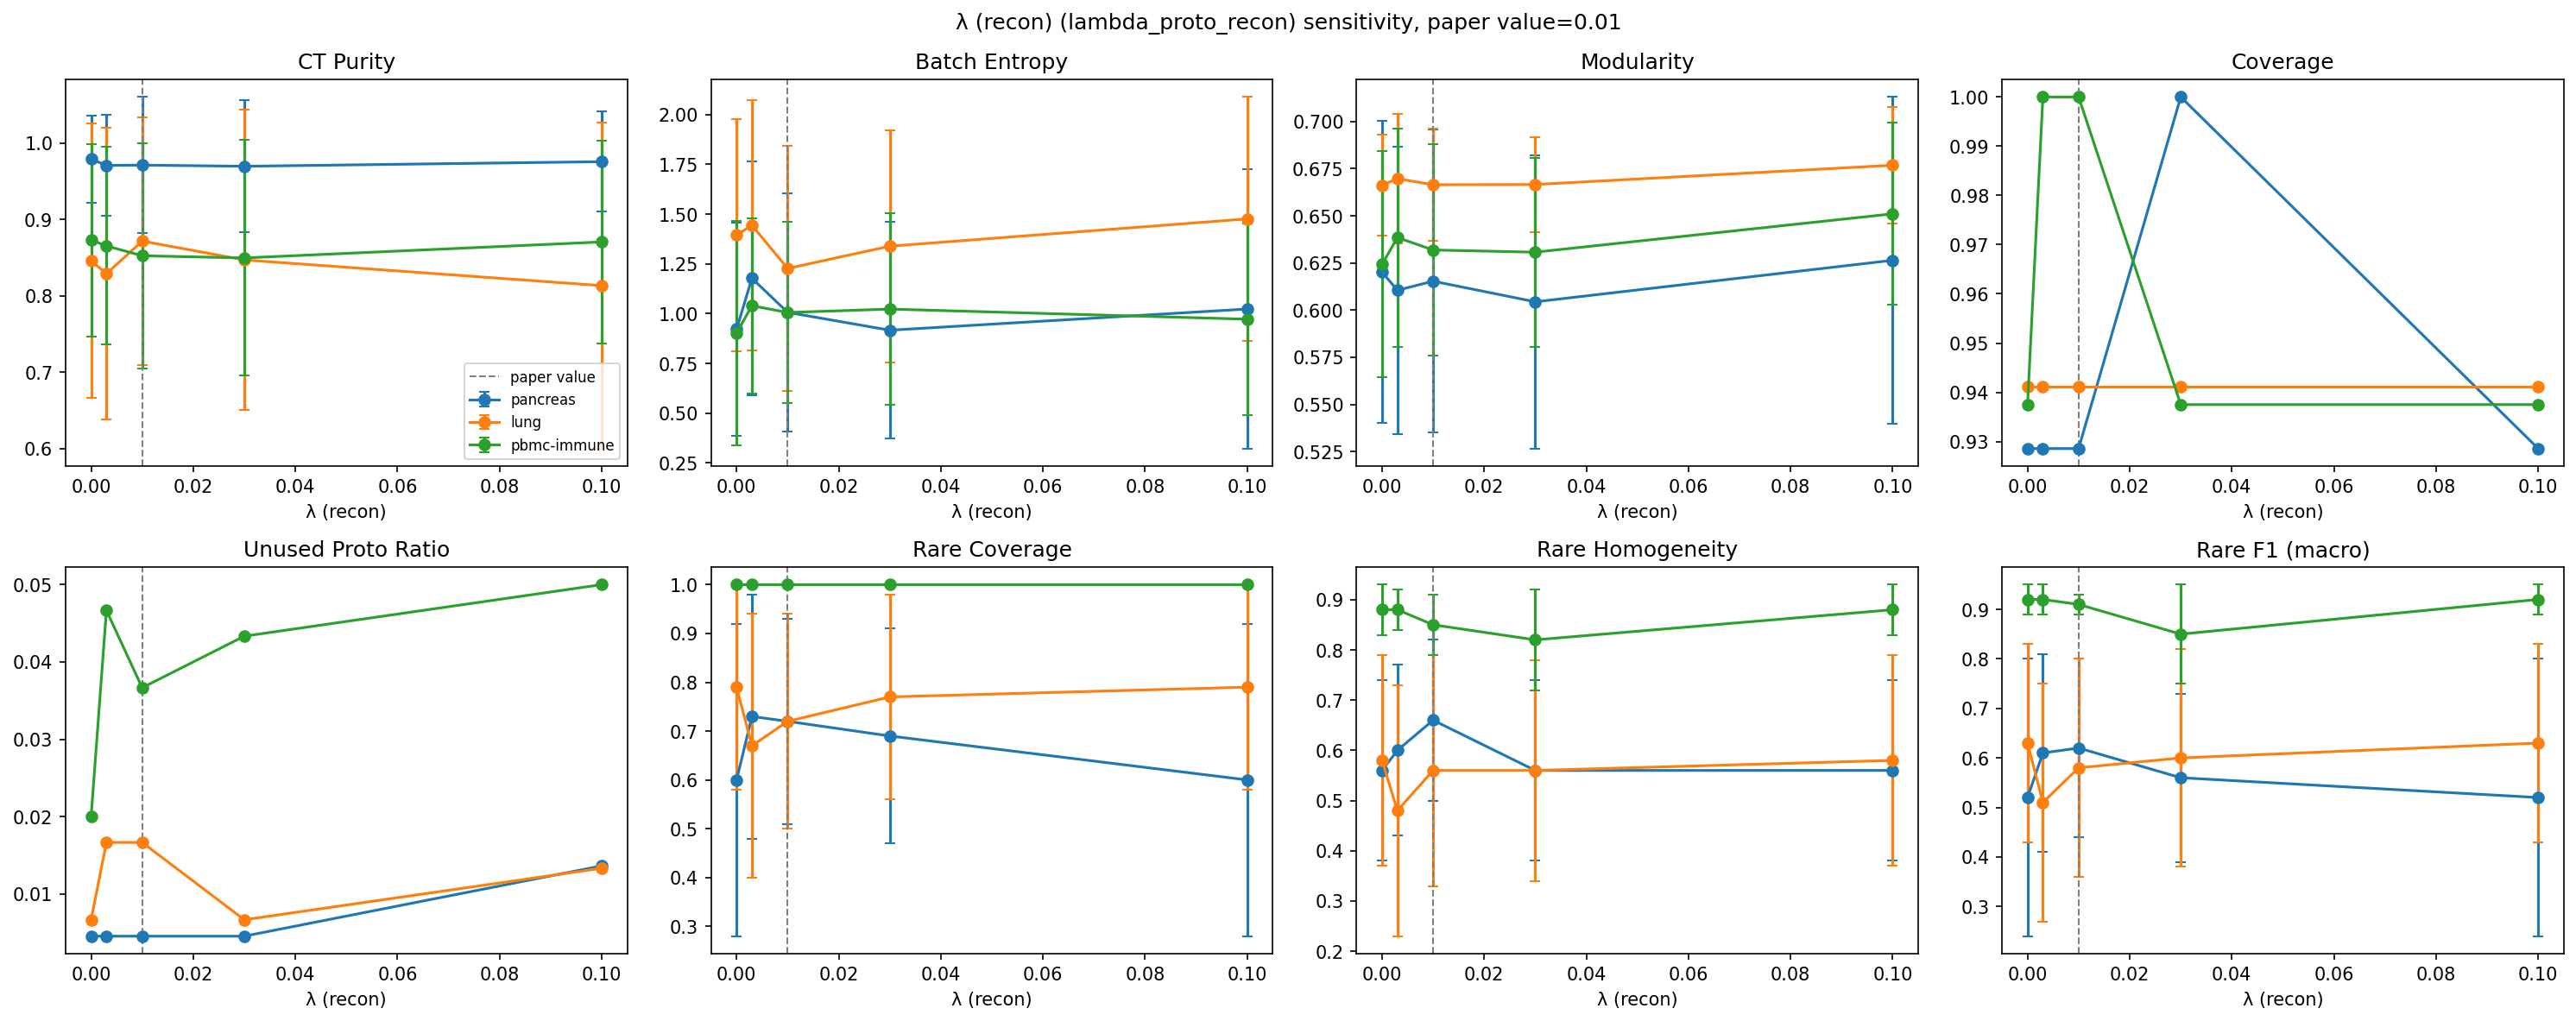

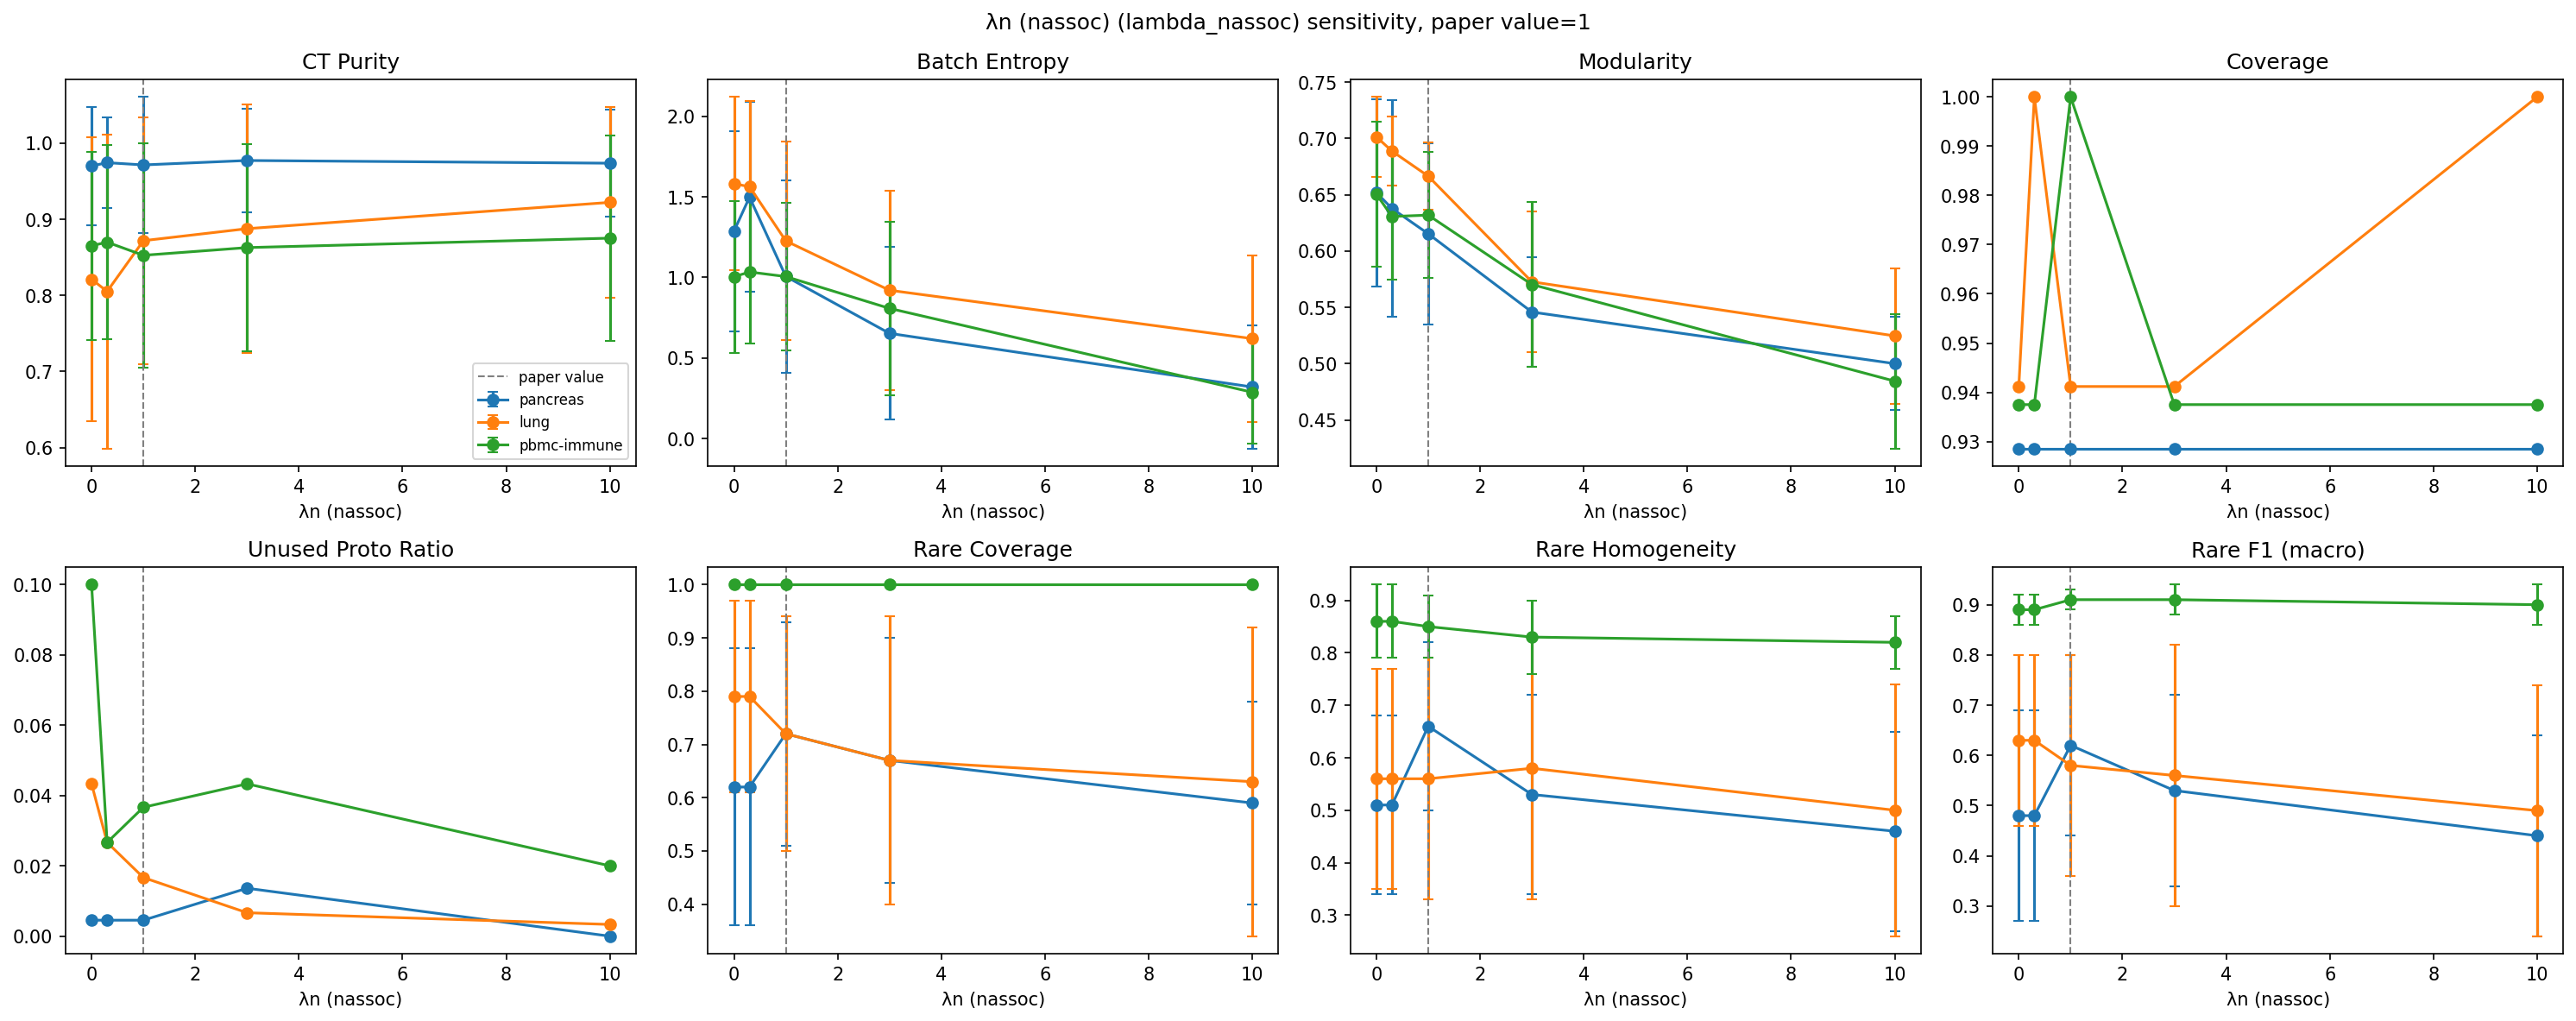

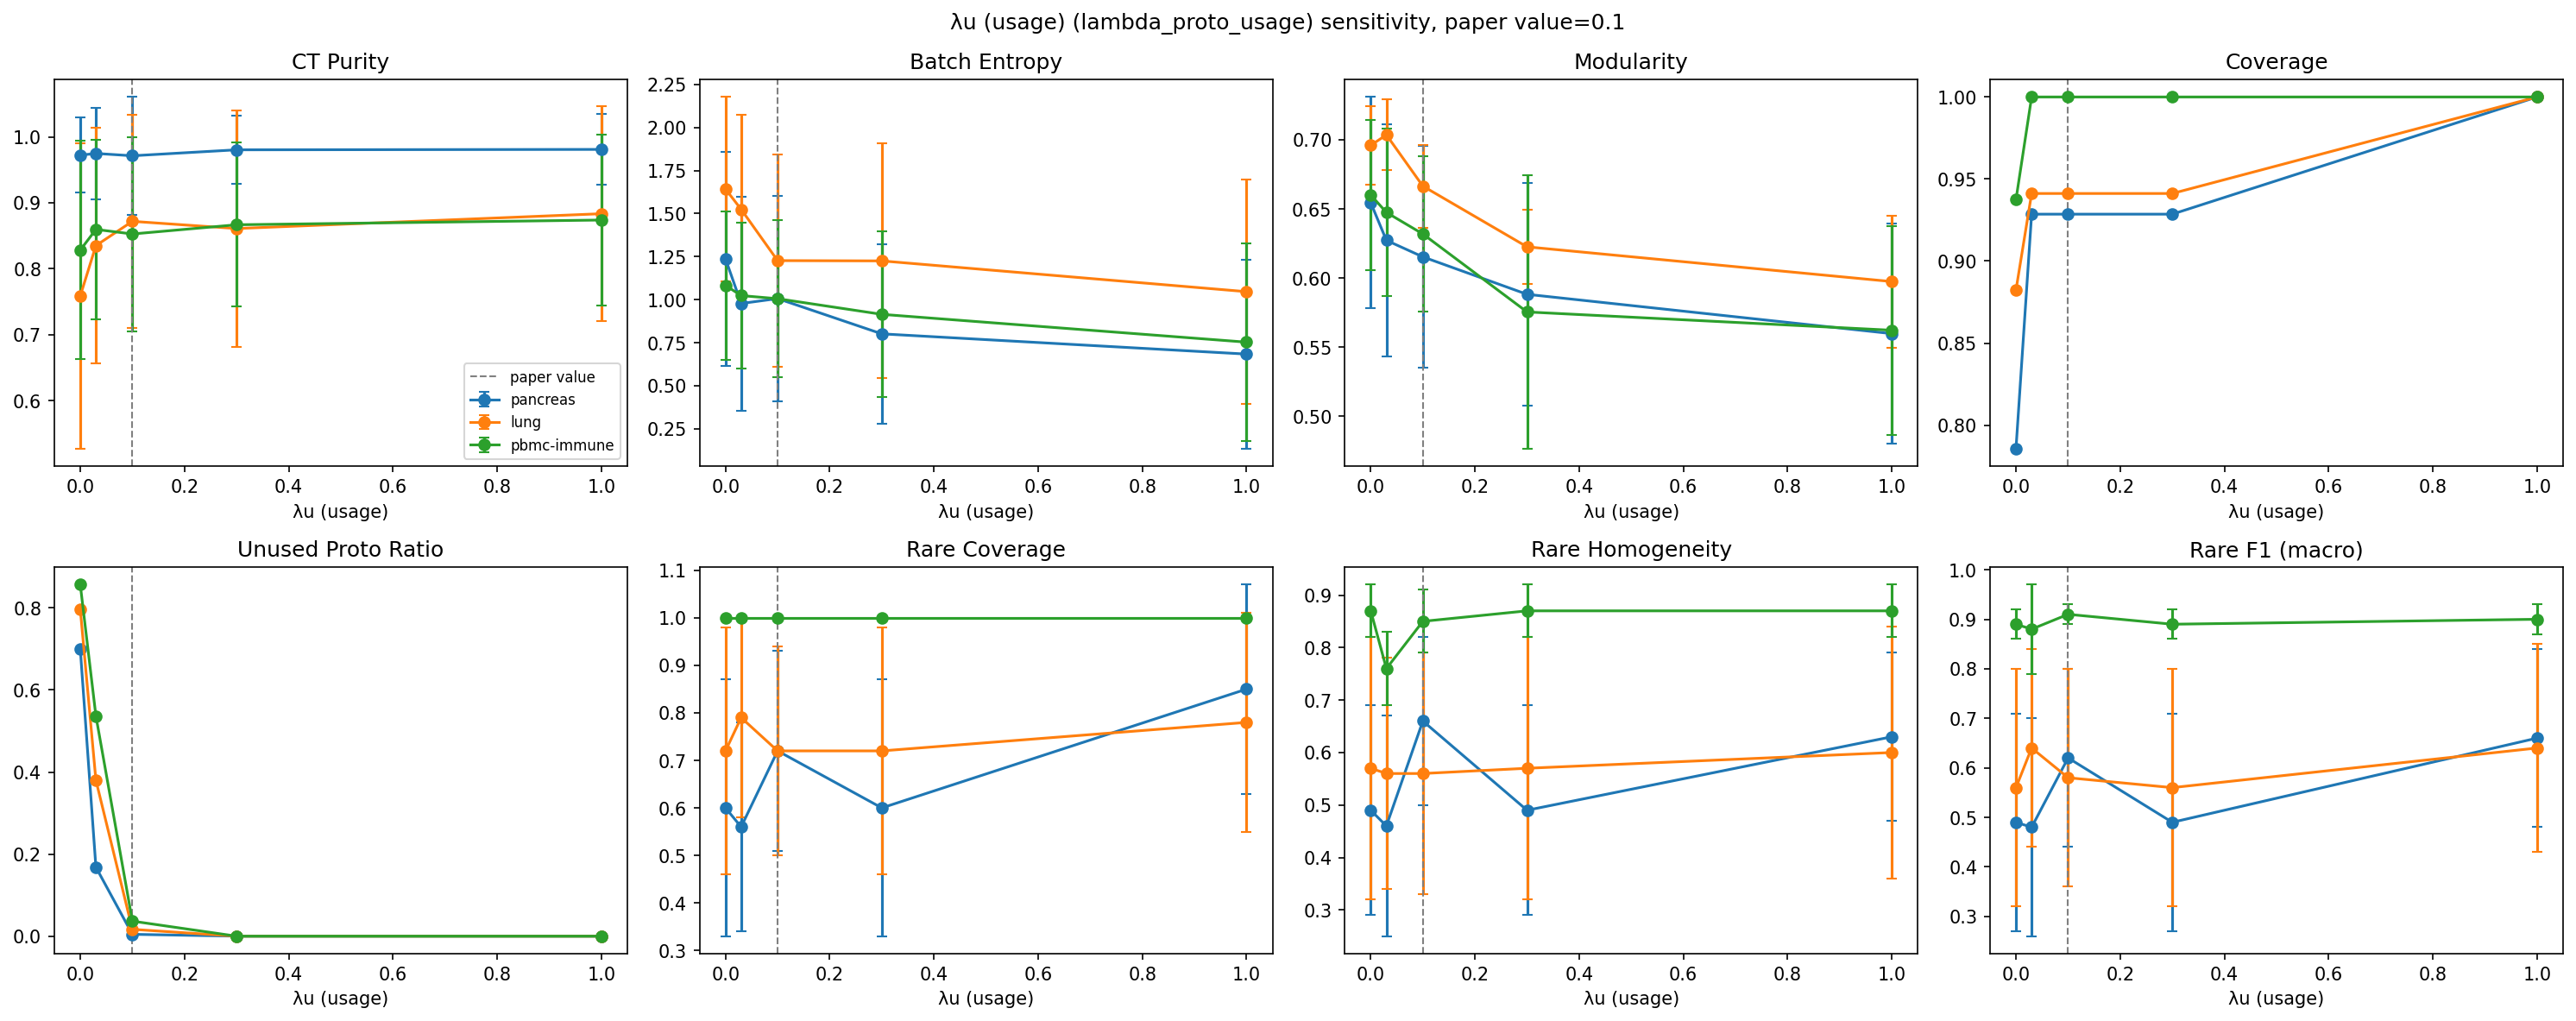

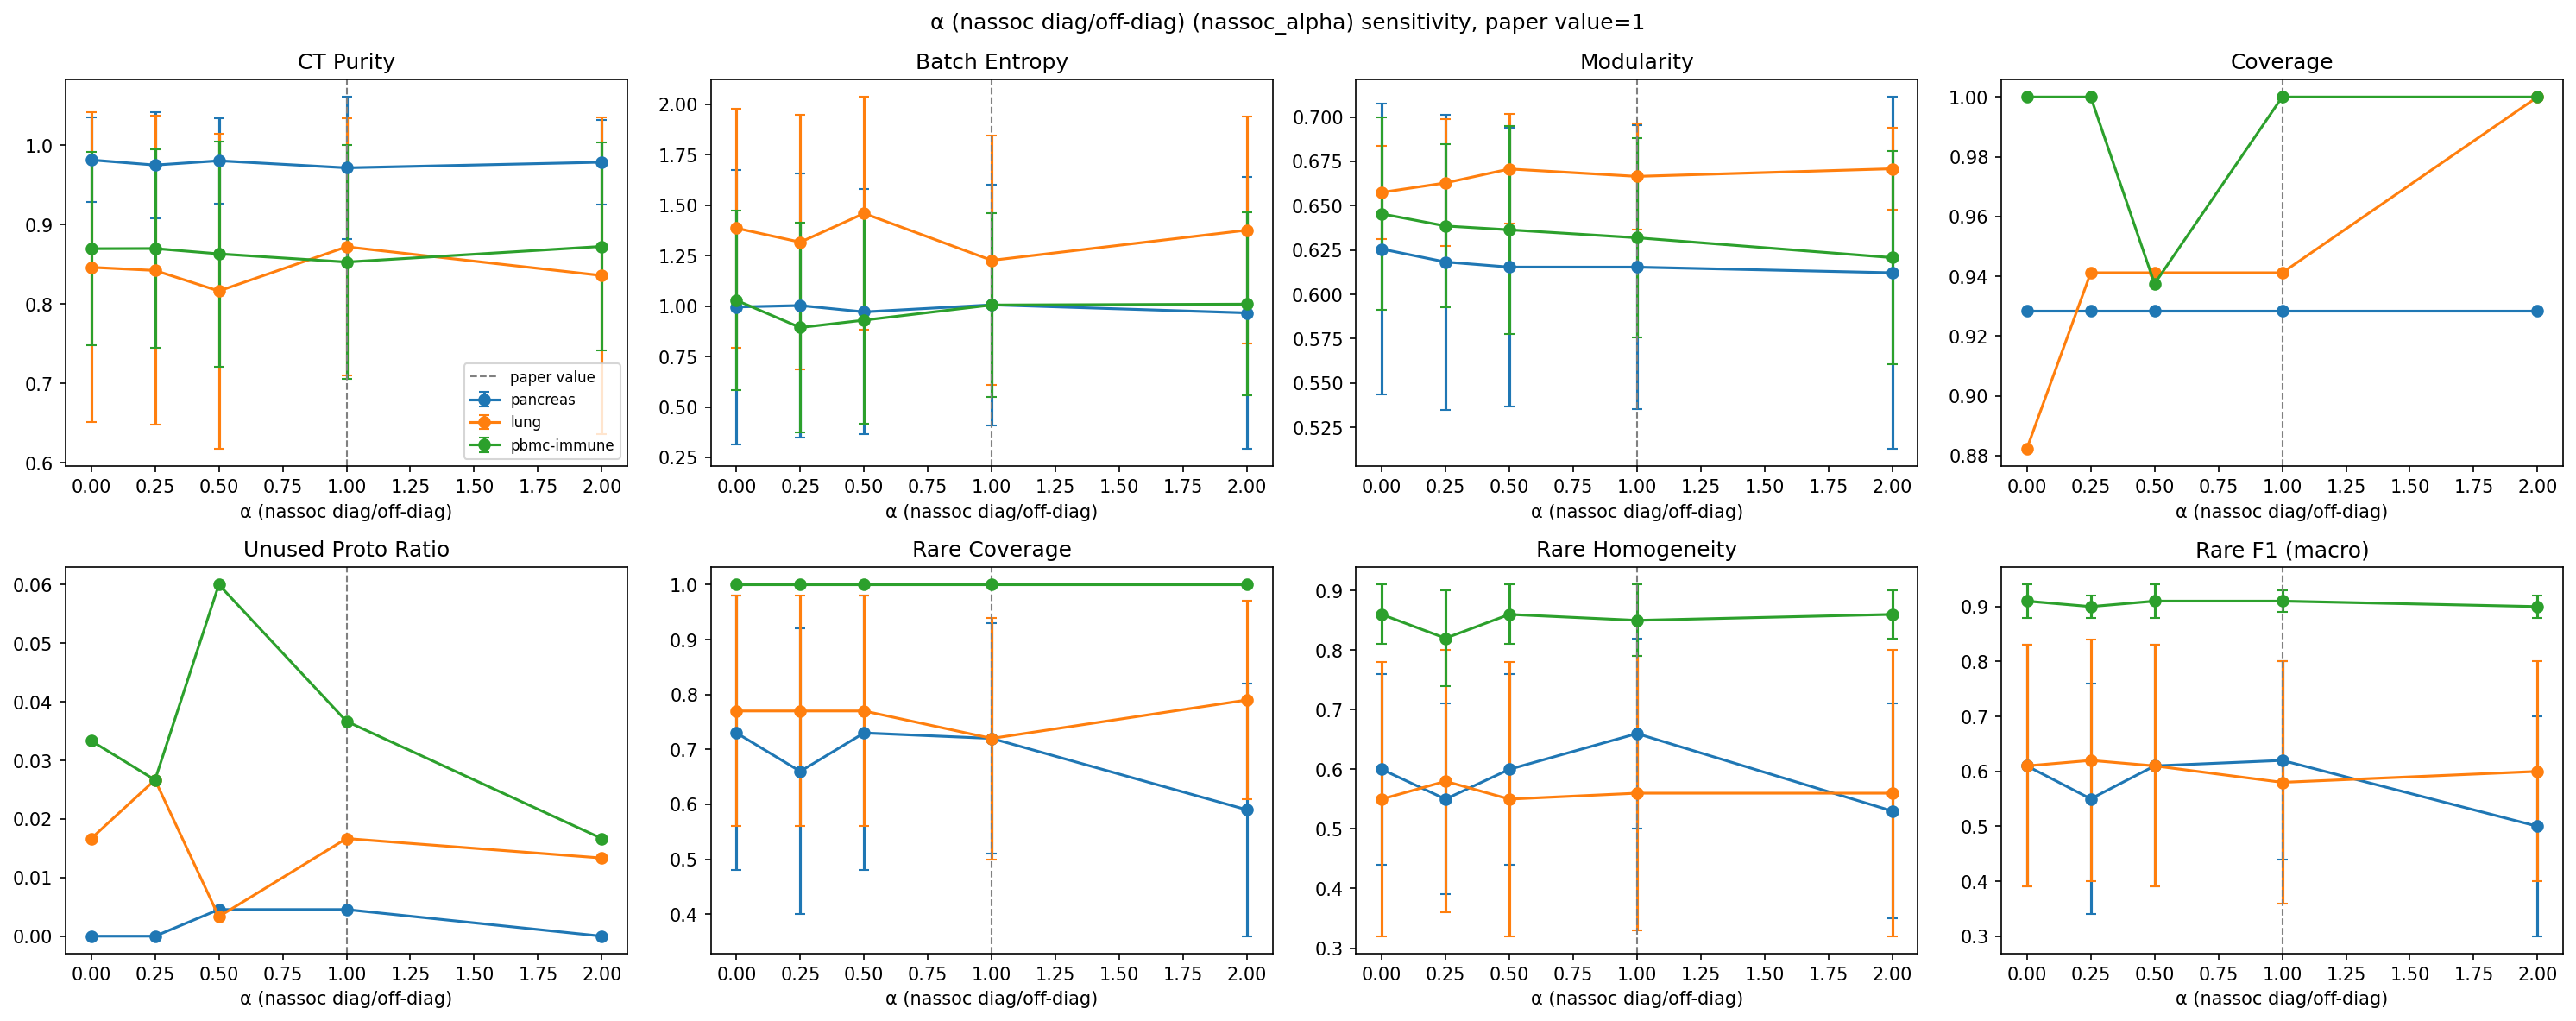

In [11]:
# --- Sensitivity plots: one figure per param, one subplot per metric, dashed vline at paper's value ---
metrics_to_plot = [label for _, _, label in TASK1_PAIRS + RARE_PAIRS]
for param, meta in PARAM_META.items():
    df = param_long[param]
    n = len(metrics_to_plot)
    fig, axes = plt.subplots(2, (n + 1) // 2, figsize=(5 * ((n + 1) // 2), 8))
    axes = axes.ravel()
    for ax, label in zip(axes, metrics_to_plot):
        for ds_id in results:
            sub = df[(df.dataset == ds_id) & (df.metric == label)].sort_values('value')
            if sub['mean'].isna().all():
                continue
            ax.errorbar(sub['value'], sub['mean'], yerr=sub['std'].fillna(0), marker='o', label=ds_id, capsize=3)
        ax.axvline(meta['default'], color='gray', linestyle='--', linewidth=1, label='paper value' if ax is axes[0] else None)
        ax.set_title(label)
        ax.set_xlabel(meta['symbol'])
    axes[0].legend(fontsize=8)
    fig.suptitle(f"{meta['symbol']} ({param}) sensitivity, paper value={meta['default']:g}")
    fig.tight_layout()
    plt.show()

### Component-specific diagnostics

Prototype redundancy (cosine similarity between prototype vectors) is the direct diagnostic for
the $\lambda_n$ / $\alpha$ sweeps; active-prototype count is the direct diagnostic for the
$\lambda_u$ sweep -- pairing each swept parameter with the diagnostic it's actually supposed to
move, same convention as `component_ablation.ipynb`.

In [12]:
diag_cols = ['proto_cosine_sim_mean', 'proto_cosine_sim_max', 'n_active_prototypes', 'K', 'active_frac']
df_ablation[[c for c in diag_cols if c in df_ablation.columns]]

n_active_prototypes    K  \
dataset     variant                                                   
pancreas    Full model (paper defaults)                    219  220   
            λ (recon)=0                                    219  220   
            λ (recon)=0.003                                219  220   
            λ (recon)=0.03                                 219  220   
            λ (recon)=0.1                                  217  220   
            λn (nassoc)=0                                  219  220   
            λn (nassoc)=0.3                                219  220   
            λn (nassoc)=3                                  217  220   
            λn (nassoc)=10                                 220  220   
            λu (usage)=0                                    66  220   
            λu (usage)=0.03                                183  220   
            λu (usage)=0.3                                 220  220   
            λu (usage)=1                                   220  220   
            α (nassoc diag/off-diag)=0                     220  220   
            α (nassoc diag/off-diag)=0.25                  220  220   
            α (nassoc diag/off-diag)=0.5                   219  220   
            α (nassoc diag/off-diag)=2                     220  220   
lung        Full model (paper defaults)                    295  300   
            λ (recon)=0                                    298  300   
            λ (recon)=0.003                                295  300   
            λ (recon)=0.03                                 298  300   
            λ (recon)=0.1                                  296  300   
            λn (nassoc)=0                                  287  300   
            λn (nassoc)=0.3                                292  300   
            λn (nassoc)=3                                  298  300   
            λn (nassoc)=10                                 299  300   
            λu (usage)=0                                    61  300   
            λu (usage)=0.03                                186  300   
            λu (usage)=0.3                                 300  300   
            λu (usage)=1                                   300  300   
            α (nassoc diag/off-diag)=0                     295  300   
            α (nassoc diag/off-diag)=0.25                  292  300   
            α (nassoc diag/off-diag)=0.5                   299  300   
            α (nassoc diag/off-diag)=2                     296  300   
pbmc-immune Full model (paper defaults)                    289  300   
            λ (recon)=0                                    294  300   
            λ (recon)=0.003                                286  300   
            λ (recon)=0.03                                 287  300   
            λ (recon)=0.1                                  285  300   
            λn (nassoc)=0                                  270  300   
            λn (nassoc)=0.3                                292  300   
            λn (nassoc)=3                                  287  300   
            λn (nassoc)=10                                 294  300   
            λu (usage)=0                                    43  300   
            λu (usage)=0.03                                139  300   
            λu (usage)=0.3                                 300  300   
            λu (usage)=1                                   300  300   
            α (nassoc diag/off-diag)=0                     290  300   
            α (nassoc diag/off-diag)=0.25                  292  300   
            α (nassoc diag/off-diag)=0.5                   282  300   
            α (nassoc diag/off-diag)=2                     295  300   

                                           active_frac  
dataset     variant                                     
pancreas    Full model (paper defaults)       0.995455  
            λ (recon)=0                       0.995455  
            λ (recon)=0.003                   0.995

## Notes / next steps

In [13]:
# - Claim being tested per parameter:
#     lambda (recon): purity/modularity should stay flat across the grid (paper's own claim,
#       already shown at the two endpoints -- 0 vs. 0.01 -- in component_ablation.ipynb's
#       no_recon arm); this sweep fills in the intermediate points and adds 0.03/0.1 to check
#       whether *over*-weighting recon starts fighting the affinity-driven terms.
#     lambda_n (nassoc): purity and prototype_redundancy (proto_cosine_sim_mean) should both
#       degrade as lambda_n -> 0, matching the no_nassoc ablation row; the question this sweep
#       actually answers is whether 1.0 sits on a plateau or a knife-edge relative to 0.3/3.0/10.0.
#     lambda_u (usage): rare-cell coverage/homogeneity and n_active_prototypes should both drop
#       as lambda_u -> 0 (dead-proto collapse), matching the no_usage ablation row; check whether
#       over-weighting (0.3/1.0) trades this off against purity/modularity instead.
#     alpha (nassoc diag/off-diag): alpha=0 disables the inter-prototype redundancy term entirely
#       (pure compactness, no distinctness pressure) -- watch proto_cosine_sim_max specifically,
#       it's the metric alpha is supposed to control and purity/modularity may stay flat while it moves.
# - If a swept value makes a metric *non-monotonic* (worse than both neighbors), flag it explicitly --
#   that's evidence the paper's fixed values sit in/near a local optimum, which is a stronger
#   response to nG29 than "the paper's choice happens to be fine."
# - Extending to lung / pbmc-immune: uncomment the "Run: Lung + PBMC" cell above -- no other code
#   changes needed, RUN_TAG-prefixed folder names already avoid collisions across datasets/notebooks.